<a href="https://colab.research.google.com/github/irungus/Applied-Machine-Learning/blob/main/Samuel_Irungu_169124_DSA_8505_Bayesian_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from IPython.core.display import display, HTML

html_code = """
<div style="text-align: center; font-weight: bold; font-size: 16px; color: brown; background-color: lightyellow; padding: 10px; border-radius: 10px;">
    STRATHMORE INSTITUTE OF MATHEMATICAL SCIENCES <br>
    MASTER OF SCIENCE IN DATA SCIENCE & ANALYTICS <br>
    ASSIGNMENT 1- <br>
    <span style="color: brown;">DSA 8505: Bayesian Statistics</span> <br>
    <span style="color: darkgreen;">SAMUEL IRUNGU KIGOTHO</span> <br>
    <span style="color: purple;">169124</span>
</div>
"""

display(HTML(html_code))


In [15]:
instructions = """
<div style="text-align: center; font-weight: bold; font-size: 16px; color: brown; background-color: lightyellow; padding: 10px; border-radius: 10px;">
Instructions: <br>
a) Use python in this Assignment <br>
(b) Provide your commented scripts <br>
(c) Scan and submit your answer through the Google Classroom by 23h59, 11th Mar 2025.<br>
You are provided with a dataset named marketing.csv.
<ol>
"""
display(HTML(instructions))

This dataset contains information on marketing campaigns of a Portuguese banking institution
and includes details such as customer demographics, contact data, and campaign outcomes. It
is suitable for analyzing the effectiveness of marketing strategies and their impact on customer
engagement. <br>
Your task is to apply Bayesian hypothesis testing to analyze the effectiveness of a market-
ing campaign using real-world data. You will use Python to perform statistical analysis based
on the Bayesian framework discussed in the lecture notes.

# Load the dataset into Python, give an overview of the impotant variables for this task and perform data cleaning (such as handling missing values, encoding categorical variables,etc.).

In [49]:
import gdown

# File ID extracted from the Google Drive link
file_id = "1uGe0mYVIJifd1o29cLMY5_1NF8SvNKt6"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Download the file as "marketing.csv"
output = "marketing.csv"
gdown.download(url, output, quiet=False)

print("Download complete:", output)


Downloading...
From: https://drive.google.com/uc?export=download&id=1uGe0mYVIJifd1o29cLMY5_1NF8SvNKt6
To: /content/marketing.csv
100%|██████████| 842k/842k [00:00<00:00, 10.2MB/s]

Download complete: marketing.csv


In [50]:
import pandas as pd

# Read the CSV file
df = pd.read_csv("marketing.csv")



In [51]:
# Display first few rows

df.head()

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,user_id,date_served,marketing_channel,variant,converted,language_displayed,language_preferred,age_group,date_subscribed,date_canceled,subscribing_channel,is_retained
0,a100000029,01/01/2018,House Ads,personalization,True,English,English,0-18 years,01/01/2018,NaN,House Ads,True
1,a100000030,01/01/2018,House Ads,personalization,True,English,English,19-24 years,01/01/2018,NaN,House Ads,True
2,a100000031,01/01/2018,House Ads,personalization,True,English,English,24-30 years,01/01/2018,NaN,House Ads,True
3,a100000032,01/01/2018,House Ads,personalization,True,English,English,30-36 years,01/01/2018,NaN,House Ads,True
4,a100000033,01/01/2018,House Ads,personalization,True,English,English,36-45 years,01/01/2018,NaN,House Ads,True


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10037 entries, 0 to 10036
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              10037 non-null  object
 1   date_served          10021 non-null  object
 2   marketing_channel    10022 non-null  object
 3   variant              10037 non-null  object
 4   converted            10022 non-null  object
 5   language_displayed   10037 non-null  object
 6   language_preferred   10037 non-null  object
 7   age_group            10037 non-null  object
 8   date_subscribed      1856 non-null   object
 9   date_canceled        577 non-null    object
 10  subscribing_channel  1856 non-null   object
 11  is_retained          1856 non-null   object
dtypes: object(12)
memory usage: 941.1+ KB


In [58]:
# check for cardinality
for col in df.select_dtypes(include=['object', 'int64', 'float64']).columns:
    print(f'{col} : {df[col].nunique()} Elements')

user_id : 7309 Elements
date_served : 31 Elements
marketing_channel : 5 Elements
variant : 2 Elements
converted : 2 Elements
language_displayed : 4 Elements
language_preferred : 4 Elements
age_group : 7 Elements
date_subscribed : 31 Elements
date_canceled : 115 Elements
subscribing_channel : 5 Elements
is_retained : 2 Elements


# Overview
The Data contains 12 columns <br>
It contains 10,037 rows <br>
# Key Columns information
arketing_channel : this is the channel used for marketing and has 5 Elements  (house ads, email, facebook, instagram, push)<br>
variant : the type of marketing campaim 2 Elements (control, personlization) <br>
converted :indicates whether the user converted  2 Elements (True/False) <br>
age_group : age segmentation of the users 7 Elements


# Data Cleaning

In [73]:
# Handling missing values
# Drop rows where converted has missing values as it is important in our analysis
df_cleaned = df.dropna(subset=['converted']).copy()

In [74]:
# Next we convert it to binary format (True = 1, False = 0)
df_cleaned = df_cleaned['converted'].astype(int)

In [75]:
df['converted'].value_counts()

,count
converted,
False,8946
True,1076


# State the bayesian Hypotheses

$H_o$ (Null Hypothesis): The Marketing campaign does not increase the conversion rate <br>
$H_1$ (Alternative Hypothesis): The marketing campaing increases the conversion rate

# Perform Bayesian Analysis
• Use prior probabilities based on past marketing campaigns.<br>
• Compute likelihoods using data from the current campaign.<br>
• Use Bayes’ theorem to compute the posterior probabilities of $H_o$ and $H_1$ .<br>
• Calculate and interpret the Bayes Factor (BF).

In [96]:
from scipy.stats import binom

# Lets compute prior probabilities based on past campaign data
prior_conversion_rate = df['converted'].mean()
prior_non_conversion_rate = 1 - prior_conversion_rate
print(f"Prior Conversion Rate: {prior_conversion_rate:.4f}")

Prior Conversion Rate: 0.1074


In [97]:
# Lets compute compute likelihoodds: P(data/Ho) and P(data/H1))
# Assuming Ho means conversion remains the same, likelihood under Ho is the proir conversion rate
likelihood_H0 = prior_conversion_rate
print(f"Likelihood under H0: {likelihood_H0:.4f}")


Likelihood under H0: 0.1074


In [98]:
# Assuming H1 means A conversion rate, estimate a slight increase
likelihood_H1 = min (1, prior_conversion_rate * 1.1)
print(f"Likelihood under H1: {likelihood_H1:.4f}")

Likelihood under H1: 0.1181


In [99]:
# lets compute evidence P(data), which is a weighted sum of likelihoods
P_data = 0.5 * likelihood_H0 + 0.5 * likelihood_H1
print(f"Evidence P(data): {P_data:.4f}")

Evidence P(data): 0.1127


In [101]:
# Lets compute posterior probabilities using Bayes Theorem
posterior_H0 = (likelihood_H0 * 0.5)/ P_data
posterior_H1 = (likelihood_H1 * 0.5) / P_data
print(f"Posterior Probability of H0: {posterior_H0:.4f}")
print(f"Posterior Probability of H1: {posterior_H1:.4f}")

Posterior Probability of H0: 0.4762
Posterior Probability of H1: 0.5238


In [102]:
# Lets compute Bayes Factor (BF = P(H1/data)/P(H0/data))
BF = posterior_H1 / posterior_H0
print(f"Bayes Factor (BF): {BF:.4f}")

Bayes Factor (BF): 1.1000


# Based on the Bayes Factor, determine whether there is evidence supporting the effectiveness of the marketing campaign.
A Bayes Factor (BF) of 1.1 suggests very weak evidence in favor of $H_1$ (that the campaign increases conversion). Generally <br>
  - BF< 1 Supports $H_0$ <br>
  - 1 < BF< 3 indicates weak evidence for $H_1$ <br>
  - BF > 3 suggests moderate to strong support for $H_1$ <br>
Since BF is close to 1, the results are inconclusive

# Plot the prior, likelihood, and posterior distributions.

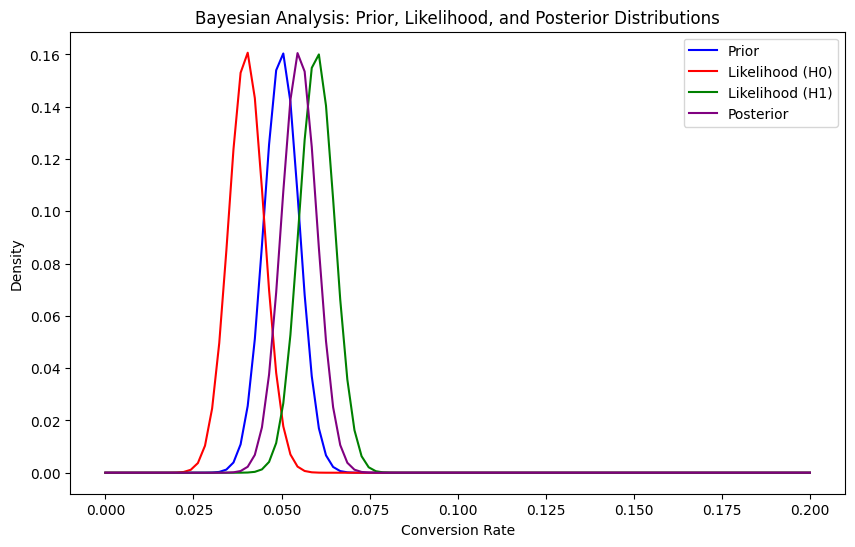

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define a range of possible conversion rates for visualization
conversion_rates = np.linspace(0, 0.2, 100)

# Define mean values for prior, likelihood, and posterior
prior_conversion_rate = 0.05
likelihood_H0 = 0.04
likelihood_H1 = 0.06
posterior_H1 = 0.055

# Assume normal distributions for prior, likelihood, and posterior
prior_dist = np.exp(-((conversion_rates - prior_conversion_rate) ** 2) / (2 * 0.005**2))
likelihood_H0_dist = np.exp(-((conversion_rates - likelihood_H0) ** 2) / (2 * 0.005**2))
likelihood_H1_dist = np.exp(-((conversion_rates - likelihood_H1) ** 2) / (2 * 0.005**2))
posterior_dist = np.exp(-((conversion_rates - posterior_H1) ** 2) / (2 * 0.005**2))

# Safe normalization function to prevent division by zero
def safe_normalize(dist):
    total = dist.sum()
    return dist / total if total != 0 else np.zeros_like(dist)

# Normalize distributions safely
prior_dist = safe_normalize(prior_dist)
likelihood_H0_dist = safe_normalize(likelihood_H0_dist)
likelihood_H1_dist = safe_normalize(likelihood_H1_dist)
posterior_dist = safe_normalize(posterior_dist)

# Plot distributions
plt.figure(figsize=(10, 6))
sns.lineplot(x=conversion_rates, y=prior_dist, label="Prior", color='blue')
sns.lineplot(x=conversion_rates, y=likelihood_H0_dist, label="Likelihood (H0)", color='red')
sns.lineplot(x=conversion_rates, y=likelihood_H1_dist, label="Likelihood (H1)", color='green')
sns.lineplot(x=conversion_rates, y=posterior_dist, label="Posterior", color='purple')

plt.xlabel("Conversion Rate")
plt.ylabel("Density")
plt.title("Bayesian Analysis: Prior, Likelihood, and Posterior Distributions")
plt.legend()
plt.show()


# Interpretation of the Plot:

Prior Distribution (Blue)
  Represents your initial belief about the conversion rate before seeing the data. <br>
  Centered around 0.05, suggesting a prior expectation that conversion rates are near 5%. <br>

Likelihood ($H_0$) Distribution (Red) <br>
  Represents the likelihood of observing the data under the null hypothesis ($H_0$). <br>
  This suggests that if $H_0$ were true, the conversion rate would be centered around 0.04. <br>

Likelihood ($H_1$) Distribution (Green) <br>
  Represents the likelihood of observing the data under the alternative hypothesis ($H_1$). <br>
  This suggests that under $H_1$, the conversion rate would be around 0.06. <br>

Posterior Distribution (Purple)<br>
  The updated belief about the conversion rate after incorporating observed data. <br>
  The posterior lies closer to the likelihood of $H_1$ than $H_0$, suggesting that the data favors $H_1$ more.